done
Initializing YuMi...
DONE


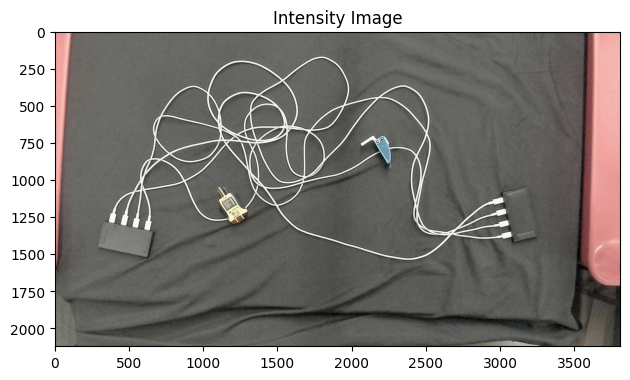

In [1]:
import matplotlib.pyplot as plt
import cv2
from decluttering.scripts.brio.brio_sensor import BRIOSensor
from decluttering.src.motion_jacobi import *

import datetime
curr_time = datetime.datetime.now().isoformat()
cam = BRIOSensor(0)
print("done")

print("Initializing YuMi...")
interface = Interface(speed=0.5)
interface.yumi.left.min_position  = YUMI_MIN_POS
interface.yumi.right.min_position = YUMI_MIN_POS
interface.close_grippers()
interface.home()
print("DONE")

for _ in range(5):   # Must take 5 idk
    img = cam.read()
        
# img_down = cv2.resize(img, (img.shape[1]//2, img.shape[0]//2))
img_down = img
plt.title("Intensity Image")
plt.imshow(img_down)
plt.tight_layout()
plt.show()
plt.imsave(f"intensity_image{curr_time}.png", img_down)

In [2]:
import PIL.Image as Image
import numpy as np
from decluttering.data.utils.detic_dataloader import DeticDataloader
import matplotlib.pyplot as plt

detic = DeticDataloader()
detic.create()
detic.default_vocab()

/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1656352465323/work/aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loading pretrained CLIP
Resetting zs_weight datasets/metadata/lvis_v1_clip_a+cname.npy


In [3]:

# im_frame1 = Image.open('/home/justinyu/multicable-decluttering/decluttering/scripts/test/intensity_image.png')
# im_frame1 = im_frame1.resize((640, 480))
im_frame1 = img_down
np_frame1 = np.array(im_frame1)
# np_frame_cropped = np_frame1[:1900, 150:3500, :] #[:1900, 150:, :]
# remove alpha channel
# np_frame1 = np_frame1[0:650, :, :3]


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride


Inference time:  1.4567537307739258


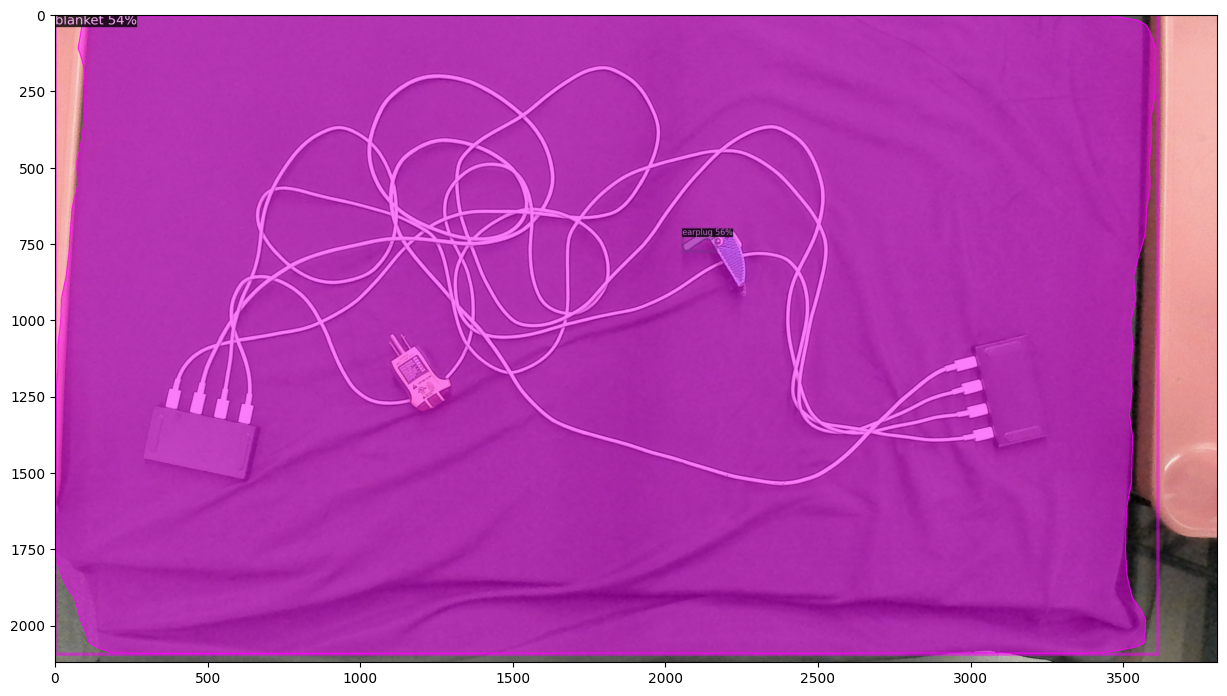

In [4]:

out = detic.predict(np_frame1)
output_im = out['vis'].get_image()
# print(output_im.shape)

plt.figure(figsize=(15, 15))
plt.imshow(output_im) 
plt.imsave(f"output_image{curr_time}.png", output_im)


In [5]:


out['boxes'][0]

height = abs(out['boxes'][0][0] - out['boxes'][0][1])
print(height)
width = abs(out['boxes'][0][2] - out['boxes'][0][3])
print(width)

if height > width:
    print('vertical')
else:
    print('horizontal')

1351.6084
1387.1053
horizontal


In [6]:
import torch
print(out['boxes'].shape)
print(out['masks'].shape)
bool_arr = []
for i in range(out['boxes'].shape[0]):
    if out['boxes'][i][0] > 100 and out['boxes'][i][2] < 3500:
        bool_arr.append(True)
    else:
        bool_arr.append(False)

out['boxes'] = out['boxes'][bool_arr]
out['masks'] = out['masks'][bool_arr]
       
print('post filter')        
print(out['boxes'].shape)
print(out['masks'].shape)
    

(2, 4)
torch.Size([2, 1, 2121, 3809])
post filter
(1, 4)
torch.Size([1, 1, 2121, 3809])


In [7]:
from decluttering.deprecated.push_through_backup2 import perform_point_grasp
from decluttering.data.utils.detic_dataloader import DeticDataloader

In [ ]:
def overlay_binary_masks():
    plt.figure()
    plt.imshow(out['masks'], cmap='YlOrRd')

# overlay_binary_masks(out['masks'])

out['boxes']= array([[2055.0483,  703.44  , 2164.4365,  777.3312]], dtype=float32)
filtered_areas= tensor([[[[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]]]], device='cuda:0')
The oriented bounding box is: ((2107.07568359375, 741.73583984375), (37.49163055419922, 109.94955444335938), 60.945396423339844)


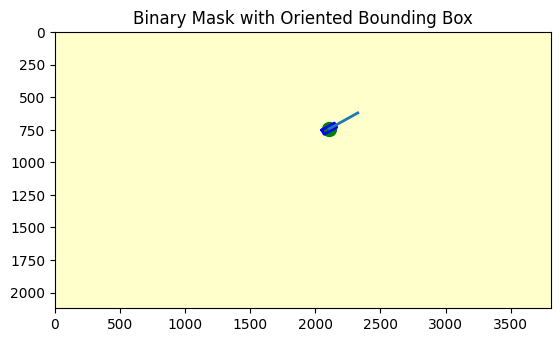

0.8741572805495796
-0.4856429232081564


In [8]:
import cv2
import numpy as np

def get_oriented_bounding_box(binary_mask):
    """
    Fit the tightest oriented bounding box around a 2D binary mask.
    
    Parameters:
    binary_mask (numpy.ndarray): A 2D numpy array representing the binary mask image.
    
    Returns:
    tuple: The (center (x, y), (width, height), angle of rotation) of the bounding box.
    """
    # Ensure the input is a binary mask
    binary_mask = np.asarray(binary_mask, dtype=np.uint8)
    
    # Find contours in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Get the largest contour, assuming the mask is connected
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Get the minimum area bounding rectangle
    rect = cv2.minAreaRect(largest_contour)
    
    return rect, largest_contour

dataloader = DeticDataloader()
print(f"{out['boxes']= }")
filtered_areas = detic.filter_mask_by_area(out['masks'], max_area=250000)
print(f"{filtered_areas= }")
rect, contour = get_oriented_bounding_box(dataloader.get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy())
print(f"The oriented bounding box is: {rect}")

def plot_mask_with_bbox(binary_mask, rect, contour):
    """
    Plot the binary mask with the oriented bounding box.
    
    Parameters:
    binary_mask (numpy.ndarray): A 2D numpy array representing the binary mask image.
    rect (tuple): The (center (x, y), (width, height), angle of rotation) of the bounding box.
    contour (numpy.ndarray): Contour of the largest component in the binary mask.
    """
    box = cv2.boxPoints(rect)
    box = np.int0(box)

    angle = rect[2]
    if rect[1][0] > rect[1][1]:
        angle = angle + 90
        
    if np.cos(np.radians(angle)) > 0:
        angle = angle + 180
    
    plt.figure()
    plt.imshow(binary_mask, cmap='YlOrRd')
    # plt.plot(contour[:, 0, 0], contour[:, 0, 1], 'r', linewidth=2)
    plt.plot(*zip(*np.vstack([box, box[0]])), 'b-', linewidth=2)
    plt.scatter(rect[0][0], rect[0][1], color='green', s=100)
    plt.plot([rect[0][0], rect[0][0]-50*np.sin(np.radians(angle))*5], [rect[0][1], rect[0][1]+50*np.cos(np.radians(angle))*5], linewidth=2)
    plt.title("Binary Mask with Oriented Bounding Box")
    plt.show()

plot_mask_with_bbox(dataloader.get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy(), rect, contour)

center = np.array(rect[0])
angle = rect[2]
if rect[1][0] > rect[1][1]:
    angle = angle + 90
    
if np.cos(np.radians(angle)) > 0:
    angle = angle + 180
    
print(-np.sin(np.radians(angle)))
print(np.cos(np.radians(angle)))



In [9]:
def drop_in_bin_local(iface, arm = 'left'):
    # iface = fullPipeline.iface
    if arm == 'left':
        place1 = [0.5327735, 0.56311663, 0.26703631]
        rot = np.array([[ 0.98123146,  0.1333951,   0.13925002], [ 0.06947921, -0.91819131,  0.38999661], [ 0.1798818,  -0.37300196, -0.91022639]])
        place1_transform = RigidTransform(
            translation=place1,
            rotation=rot,
            from_frame=YK.l_tcp_frame,
            to_frame="base_link",
        )
        iface.go_cartesian_waypoints(l_targets=[place1_transform])
    elif arm == 'right':
        place1 = [0.48272088, -0.55385822, 0.26748793] # [0.48272088, -0.55385822, 0.26748793]
        rot = np.array([[ 0.96381043, -0.19505362, -0.18172382], [-0.21366951, -0.97283961, -0.08904179], [-0.15942021,  0.12464825, -0.97930997]])
        place1_transform = RigidTransform(
            translation=place1,
            rotation=rot,
            from_frame=YK.r_tcp_frame,
            to_frame="base_link",
        )
        iface.go_cartesian_waypoints(r_targets=[place1_transform])
    elif arm == 'both':
        l_place1 = [0.5327735, 0.56311663, 0.26703631]
        l_rot = np.array([[ 0.98123146,  0.1333951,   0.13925002], [ 0.06947921, -0.91819131,  0.38999661], [ 0.1798818,  -0.37300196, -0.91022639]])
        r_place1 = [0.48272088, -0.55385822, 0.26748793]
        r_rot = np.array([[ 0.96381043, -0.19505362, -0.18172382], [-0.21366951, -0.97283961, -0.08904179], [-0.15942021,  0.12464825, -0.97930997]])
        l_place1_transform = RigidTransform(
            translation=l_place1,
            rotation=l_rot,
            from_frame=YK.l_tcp_frame,
            to_frame="base_link",
        )
        r_place1_transform = RigidTransform(
            translation=r_place1,
            rotation=r_rot,
            from_frame=YK.r_tcp_frame,
            to_frame="base_link",
        )
        iface.go_cartesian_waypoints(r_targets=[r_place1_transform], l_targets=[l_place1_transform])


    time.sleep(1)
    iface.open_grippers()

In [10]:
FIXED_DEPTH_OBJ_L = 0.042 #0.0650
FIXED_DEPTH_OBJ_R = 0.06 #0.0650
CAM_INTR = CameraIntrinsics(fx=3.43246678e+03, fy=3.44478930e+03,
           cx=1.79637288e+03, cy=1.08661527e+03, width=3840, height=2160, frame='brio')

def perform_point_grasp_local(center, angle, interface, img = None, viz=False, pin_arm=None):
    
    waypoint1 = np.array([center[0], center[1]])
    iface = interface

    print(waypoint1)
    iface.open_grippers()
    if waypoint1[0] > 1750: #prev = 550
        print("Using right arm")
        place1 = get_world_coord_from_pixel_coord(waypoint1, CAM_INTR) # convert pixel coordinates to 3d coordinates
        # place2 = get_world_coord_from_pixel_coord(waypoint2, iface.cam.intrinsics) # convert pixel coordinates to 3d coordinates
        place1 = [place1[0], place1[1], FIXED_DEPTH_OBJ_R]
        intermediate_place1 = [place1[0], place1[1], 0.26]
        print(f"{place1=}")
        print(f"{intermediate_place1=}")
        rot = get_gripper_rot(angle, iface)
        print(f"{iface.get_FK('right')=}")
        intermediate_place1_transform = RigidTransform(
            translation=intermediate_place1,
            rotation=rot,
            from_frame=YK.r_tcp_frame,
            to_frame="base_link",
        )
        place1_transform = RigidTransform(
            translation=place1,
            rotation=rot,
            from_frame=YK.r_tcp_frame,
            to_frame="base_link",
        )
        print(f"{intermediate_place1_transform=}")
        iface.go_cartesian_waypoints(r_targets=[intermediate_place1_transform])
        iface.go_linear_single(r_target=place1_transform)
        
        
        time.sleep(1)
        iface.close_grippers('right')
        time.sleep(1)
        iface.go_linear_single(r_target=intermediate_place1_transform)
        time.sleep(1)
        drop_in_bin_local(iface, arm = 'right')
        # goto_gripper_px(place1, interface)

        # time.sleep(1.5)

        # iface.close_grippers('right')
        # time.sleep(1)

        # iface.go_cartesian_waypoints(r_targets=[intermediate_place1_transform])
        # time.sleep(1)

        # drop_in_bin_local(iface, arm = 'right')

    else:
        print("Using left arm")
        place1 = get_world_coord_from_pixel_coord(waypoint1, CAM_INTR) # convert pixel coordinates to 3d coordinates
        place1 = [place1[0], place1[1], FIXED_DEPTH_OBJ_L]
        intermediate_place1 = [place1[0], place1[1], 0.26]  #prev = 0.15
        print(f"{place1=}")
        print(f"{intermediate_place1=}")
        rot = get_gripper_rot(angle, iface)
        print(f"{iface.get_FK('left')=}")
        
        intermediate_place1_transform = RigidTransform(
            translation=intermediate_place1,
            rotation=rot,
            from_frame=YK.l_tcp_frame,
            to_frame="base_link",
        )
        place1_transform = RigidTransform(
            translation=place1,
            rotation= rot,
            from_frame=YK.l_tcp_frame,
            to_frame="base_link",
        )
        print(f"{intermediate_place1_transform=}")
        iface.go_cartesian_waypoints(l_targets=[intermediate_place1_transform])
        iface.go_linear_single(l_target=place1_transform)
        time.sleep(1)
        iface.close_grippers('left')
        time.sleep(1)
        iface.go_linear_single(l_target=intermediate_place1_transform)
        time.sleep(1)
        drop_in_bin_local(iface, arm = 'left')

        # iface.go_cartesian_waypoints(l_targets=[intermediate_place1_transform, place1_transform])
        # time.sleep(1.5)

        # iface.close_grippers('left')
        # time.sleep(1)

        # iface.go_cartesian_waypoints(l_targets=[intermediate_place1_transform])
        # time.sleep(1)

        # drop_in_bin_local(iface, arm = 'left')


    time.sleep(1)
    iface.home()
    time.sleep(1)

In [ ]:
from decluttering.deprecated.push_through_backup2 import get_poi_and_vec_for_push, perform_push_through, perform_pindown, perform_pick_away, perform_point_grasp, drop_in_bin
from decluttering.deprecated.demopipeline import DemoPipeline

# def initialize_pipeline(logLevel):
#     pipeline = DemoPipeline(viz=False, loglevel=logLevel, initialize_iface=True)
#     pipeline.iface.open_grippers()
#     pipeline.iface.sync()
#     pipeline.iface.home()
#     pipeline.iface.sync()
#     return pipeline

# pipeline = initialize_pipeline('DEBUG')
interface.home()
# interface.sync()
interface.open_grippers()
# interface.sync()

print("Angle is: ", angle)

perform_point_grasp_local(center, np.radians(angle), interface)

Angle is:  240.94539642333984
[2107.07568359  741.73583984]
Using right arm
place1=[0.48507665916443, -0.07800642079262289, 0.06]
intermediate_place1=[0.48507665916443, -0.07800642079262289, 0.26]
iface.get_FK('right')=RigidTransform(rotation=np.array([[-0.94593439,  0.31667472,  0.0701802 ],
       [ 0.30502801,  0.94206661, -0.13952928],
       [-0.11029982, -0.11057862, -0.98772786]]), translation=np.array([ 0.42015523, -0.4723558 ,  0.23801976], dtype=float32), from_frame='unassigned', to_frame='world')
intermediate_place1_transform=RigidTransform(rotation=np.array([[-0.87415728, -0.48564292,  0.        ],
       [-0.48564292,  0.87415728,  0.        ],
       [ 0.        ,  0.        , -1.        ]]), translation=np.array([ 0.48507667, -0.07800642,  0.26      ], dtype=float32), from_frame='r_tcp', to_frame='base_link')
[jacobi.driver] Motors have turned off mid-motion.


LEFT GRIPPER

Angle is:  2.4895529747009277
[961.55651855 505.19812012]
Using left arm
place1=[0.547906555110846, 0.25687171788659025, 0.065]
intermediate_place1=[0.547906555110846, 0.25687171788659025, 0.26]
iface.get_FK('left')=RigidTransform(rotation=np.array([[-0.98007774, -0.19792304,  0.01655598],
       [-0.19531573,  0.97557532,  0.10052142],
       [-0.03604711,  0.09528516, -0.99479714]]), translation=np.array([0.4037098 , 0.46132854, 0.24982727], dtype=float32), from_frame='unassigned', to_frame='world')
intermediate_place1_transform=RigidTransform(rotation=np.array([[ 0.04343723,  0.99905616,  0.        ],
       [ 0.99905616, -0.04343723,  0.        ],
       [ 0.        ,  0.        , -1.        ]]), translation=np.array([0.5479066 , 0.25687173, 0.26      ], dtype=float32), from_frame='l_tcp', to_frame='base_link')
[1;33m[jacobi.driver] Motors have turned off mid-motion.[0m
[1;33m[jacobi.driver] Motors have turned off mid-motion.[0m

RIGHT GRIPPER

Angle is:  180.0
[2477.5  542. ]
Using right arm
place1=[0.5449326771275965, -0.18489587493687654, 0.065]
intermediate_place1=[0.5449326771275965, -0.18489587493687654, 0.26]
iface.get_FK('right')=RigidTransform(rotation=np.array([[-0.94592912,  0.31671029,  0.0700906 ],
       [ 0.3050734 ,  0.94205188, -0.1395295 ],
       [-0.11021941, -0.11060224, -0.98773419]]), translation=np.array([ 0.42013264, -0.4723636 ,  0.23802508], dtype=float32), from_frame='unassigned', to_frame='world')
intermediate_place1_transform=RigidTransform(rotation=np.array([[ 6.123234e-17, -1.000000e+00,  0.000000e+00],
       [-1.000000e+00, -6.123234e-17,  0.000000e+00],
       [ 0.000000e+00,  0.000000e+00, -1.000000e+00]]), translation=np.array([ 0.54493266, -0.18489587,  0.26      ], dtype=float32), from_frame='r_tcp', to_frame='base_link')